# Phase 1 — Data Cleaning & Feature Engineering
## Egypt Real Estate 2026 | PropertyFinder Dataset

This notebook takes the raw scraped dataset (39,713 listings, 53 columns) and turns it into something we can actually analyse. Think of it as prep work — washing and trimming the ingredients before cooking.

**What comes out:**
- `egypt_re_clean.csv` — the main clean dataset every other notebook reads
- `egypt_re_amenities_binary.csv` — one column per amenity (0/1), used for correlation analysis

**The pipeline, in one line:**
```
Raw CSV → Fix Dates → Deduplicate → Clean Columns → Feature Engineering → Export
```

Run cells top to bottom. Each section depends on the one before it.

## 0. Import libraries

In [52]:
import os
import ast
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# seaborn's tab10 palette — 10 distinct colours, consistent across all charts
palette  = sns.color_palette("tab10")
BUY_CLR  = palette[0]   # blue   → Buy listings
RENT_CLR = palette[1]   # orange → Rent listings
BASE_CLR = palette[2]   # green  → single-colour charts

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

# Change these paths to wherever your files actually live
RAW_PATH   = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Raw\Egypt Real Estate Data 2026.csv"
OUTPUT_DIR = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\eda_outputs_Cleaning", exist_ok=True)

print("Libraries loaded, folders ready.")

Libraries loaded, folders ready.


## 1. Load the raw data

`encoding='utf-8-sig'` silently strips the invisible BOM character Excel sometimes writes at the start of CSV files. Without it you'd get a weird extra character on the first column name.

In [53]:
df_raw = pd.read_csv(RAW_PATH, encoding="utf-8-sig", low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

dtype_table = (
    df_raw.dtypes
    .reset_index()
    .rename(columns={"index": "Column", 0: "Data Type"})
)

display(dtype_table)

Shape: 39,713 rows × 53 columns


,Column,Data Type
0,listing_id,str
1,internal_id,float64
2,category,str
3,listing_type,str
4,detail_url,str
5,property_type,str
6,offering_type,str
7,completion_status,str
8,title,str
9,price_egp,float64


In [54]:
df_raw.head(3)

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,price_period,price_currency,location_full,city,town,district,subdistrict,lat,lon,bedrooms,bathrooms,area_value,area_unit,furnished,listing_level,is_premium,is_verified,is_featured,is_new_construction,is_direct_from_dev,is_exclusive,listed_date,images_count,has_view_360,video_url,reference,rera,description,amenities,payment_method,agent_id,agent_name,agent_email,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,"56,009,081.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,"24,500,000.0000",sell,EGP,"The Lakeview Boutique Villas, 5th Settlement C...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.0406,31.5259,3,6,445.0000,sqm,NaN,premium,True,False,False,False,False,False,2026-03-03T19:15:06Z,6,False,NaN,F7QB31CGWE509V2W7DF2GARB2C,NaN,Garden Villa for Sale – Featured in Lake View ...,Balcony | Built in Wardrobes | Covered Parking...,cash,"58,866.0000",pierre osama,pierre.Osama@spade-consultancy.com,False,NaN,"5,758.0000",Spade consultancy,mohmedg.sedik@gmail.com,"1,001,436,511.0000","201,201,801,443.0000","20,221,257,340.0000",pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,"56,247,925.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,"5,145,000.0000",sell,EGP,"Village West, Sheikh Zayed Compounds, Sheikh Z...",Giza,Sheikh Zayed City,Sheikh Zayed Compounds,Village West,30.0481,31.0201,2,2,123.0000,sqm,PARTLY,premium,True,False,False,False,False,False,2026-03-04T11:24:23Z,10,False,NaN,rb304,NaN,For Sale: Finished Apartment with ACs in Villa...,Balcony | Built in Wardrobes | Central A/C | C...,cash,"67,166.0000",Rana Bahaa ElDeen,ranoushamer901@gmail.com,False,NaN,492.0000,Abrag Real Estate,snawara71@gmail.com,"201,001,188,088.0000","201,007,169,666.0000","20,221,257,340.0000",ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,"56,253,883.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,"10,800,000.0000",sell,EGP,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.0123,31.5795,4,4,250.0000,sqm,NaN,premium,True,False,False,False,False,False,2026-03-04T14:03:51Z,13,False,NaN,250pncash,NaN,Palm Hills New Cairo Apartment BUA: 250sqm 4 B...,Balcony | Built in Wardrobes | Central A/C | C...,cash,"47,158.0000",Ashraf Shaaban,ashrafsobhy99@hotmail.com,False,English | Arabic,"5,279.0000",Premises,mahmouddessam@hotmail.com,"201,005,133,389.0000","201,090,963,241.0000","20,221,257,340.0000",ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


### 1.1 Missing value analysis

Before touching anything, we need to know how much data is actually there. The rule used here: columns missing more than **40%** of their values get dropped — you can't reliably fill in that many gaps. A few exceptions apply where we can impute meaningfully.

In [55]:
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
null_df  = null_pct[null_pct > 0].reset_index()
null_df.columns = ["column", "null_pct"]

high_null = null_df[null_df["null_pct"] > 40]
print(f"Columns with >40% missing: {len(high_null)}")
print(high_null.to_string(index=False))

Columns with >40% missing: 5
           column  null_pct
             rera  100.0000
        video_url   99.4914
  agent_languages   76.9043
completion_status   50.2354
   payment_method   49.7923


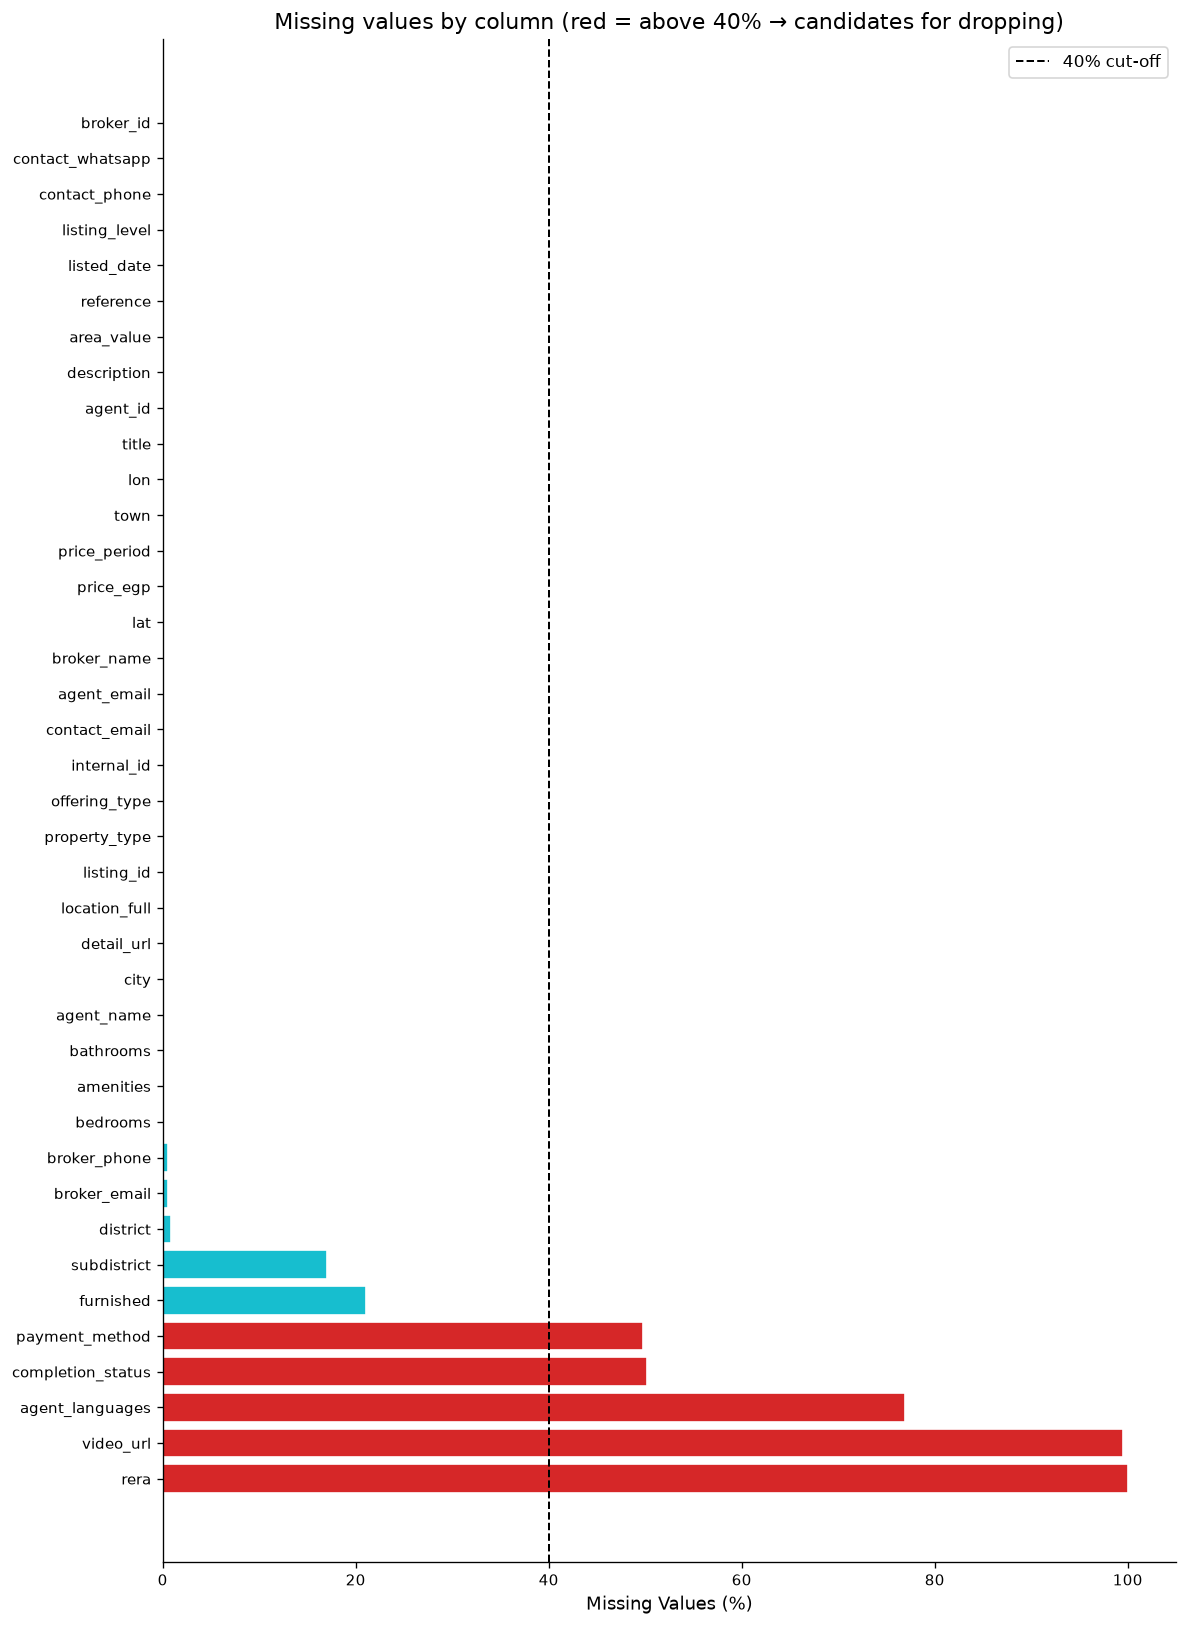

In [56]:
fig, ax = plt.subplots(figsize=(10, max(4, len(null_df) * 0.35)))

# red = above the 40% cutoff, grey = below
bar_colors = [palette[3] if v > 40 else palette[9] for v in null_df["null_pct"]]
ax.barh(null_df["column"], null_df["null_pct"], color=bar_colors, edgecolor="white")
ax.axvline(40, color="black", linestyle="--", linewidth=1.2, label="40% cut-off")
ax.set_xlabel("Missing Values (%)")
ax.set_title("Missing values by column (red = above 40% → candidates for dropping)")
ax.legend()

plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\eda_outputs_Cleaning/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# Columns we keep even if they're >40% null, because we can impute them
KEEP_EVEN_IF_NULL = ["furnished", "completion_status", "payment_method",
                     "district", "subdistrict", "town"]

DROP_HIGH_NULL = [col for col in high_null["column"] if col not in KEEP_EVEN_IF_NULL]

print("Will DROP these high-null columns:")
for c in DROP_HIGH_NULL:
    print(f"  {c}")

Will DROP these high-null columns:
  rera
  video_url
  agent_languages


## 2. Make a working copy

Never touch `df_raw`. If something goes wrong downstream, the original is still there to check against. All cleaning happens on `df`.

In [58]:
df = df_raw.copy()

cols_to_drop = [c for c in DROP_HIGH_NULL if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Working copy ready. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Dropped {len(cols_to_drop)} high-null columns.")

Working copy ready. Shape: 39,713 rows × 50 columns
Dropped 3 high-null columns.


## 3. Remove duplicate listings

Web scrapers often hit the same listing on different days. We keep only the most recently scraped version per `listing_id` — it has the freshest price and status.

In [59]:
if "scraped_at" in df.columns:
    df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce", utc=True)

rows_before = len(df)

if "listing_id" in df.columns:
    df.sort_values("scraped_at", ascending=False, inplace=True, na_position="last")
    df.drop_duplicates(subset=["listing_id"], keep="first", inplace=True)
    df.reset_index(drop=True, inplace=True)

rows_after = len(df)

print(f"Before: {rows_before:,} rows")
print(f"After : {rows_after:,} rows  (removed {rows_before - rows_after:,} duplicates)")

Before: 39,713 rows
After : 39,713 rows  (removed 0 duplicates)


## 4. Fix the listed dates

Almost every `listed_date` in the raw data shows a date in early 2026 — that's just when the scraper ran, not when the property was posted.

A real 4-year dataset should have listings spread across 2022–2026. We redistribute them using a model built around three real patterns:

| Factor | What it models |
|---|---|
| Growth curve | The Egyptian property market grew fast from 2022 to 2026 |
| Seasonality | Listings peak Feb–Apr and Sep–Nov; summer is slow |
| Buy vs Rent | Rent spikes in September; North Coast Buy spikes in summer |

Without this step, every time-series chart would be flat.

In [60]:
START_DATE = "2022-01-01"
END_DATE   = "2026-03-31"

months   = pd.date_range("2022-01", "2026-03", freq="MS")
yr_float = months.year + (months.month - 1) / 12

yr_float = np.array(yr_float)  

trend = 1 / (1 + np.exp(-2.5 * (yr_float - 2024.5)))

seasonal_idx = {
    1: 0.85, 2: 1.10, 3: 1.25, 4: 1.20, 5: 1.00,
    6: 0.75, 7: 0.65, 8: 0.70, 9: 1.15, 10: 1.20, 11: 1.10, 12: 0.80,
}
seasonality = np.array([seasonal_idx[m.month] for m in months])

raw_weight  = trend * seasonality  
month_table = pd.DataFrame({
    "month_start": months,
    "year":        months.year,
    "month":       months.month,
    "weight":      raw_weight / raw_weight.sum(),
})

In [61]:
# Step 2: per-segment adjustments (Buy vs Rent, North Coast, day-of-week)
OFFERING_SEASON = {
    "Buy":  {1:0.90, 2:1.15, 3:1.30, 4:1.25, 5:1.05,
             6:0.70, 7:0.60, 8:0.65, 9:1.10, 10:1.20, 11:1.15, 12:0.85},
    "Rent": {1:0.80, 2:1.05, 3:1.20, 4:1.15, 5:0.95,
             6:0.80, 7:0.75, 8:0.80, 9:1.25, 10:1.20, 11:1.05, 12:0.75},
}

NORTH_COAST_BUY_BOOST = {6: 1.8, 7: 2.2, 8: 2.0, 9: 1.5}

# Egypt works Sun–Thu; Friday and Saturday are quieter
DOW_WEIGHTS = {0: 1.0, 1: 1.1, 2: 1.1, 3: 1.05, 4: 0.60, 5: 0.50, 6: 0.95}

all_dates = pd.date_range(START_DATE, END_DATE, freq="D")
date_df   = pd.DataFrame({
    "date":  all_dates,
    "year":  all_dates.year,
    "month": all_dates.month,
    "dow":   all_dates.dayofweek,
})

print(f"Calendar built: {len(date_df):,} days from {START_DATE} to {END_DATE}")

Calendar built: 1,551 days from 2022-01-01 to 2026-03-31


In [62]:
# Step 3: assign a new date to each row
# Fixed seed (42) means you get the same dates every time you run this cell
rng       = np.random.default_rng(42)
new_dates = []

print("Redistributing dates... (30-60 seconds for ~39k rows)")

for _, row in df.iterrows():
    offering     = str(row.get("offering_type", "Buy")).strip()
    offering_key = "Buy" if offering.lower() == "buy" else "Rent"
    city         = str(row.get("city", "Cairo")).lower()

    mw = month_table["weight"].values.copy()

    for i, mr in month_table.iterrows():
        mw[i] *= OFFERING_SEASON[offering_key][mr["month"]]
        if "north coast" in city and offering_key == "Buy":
            if mr["month"] in NORTH_COAST_BUY_BOOST:
                mw[i] *= NORTH_COAST_BUY_BOOST[mr["month"]]

    mw /= mw.sum()

    chosen_idx  = rng.choice(len(month_table), p=mw)
    yr          = int(month_table.iloc[chosen_idx]["year"])
    mon         = int(month_table.iloc[chosen_idx]["month"])

    day_pool    = date_df[(date_df["year"] == yr) & (date_df["month"] == mon)]
    dw          = day_pool["dow"].map(DOW_WEIGHTS).values.astype(float)
    dw         /= dw.sum()
    chosen_date = rng.choice(day_pool["date"].values, p=dw)
    new_dates.append(pd.Timestamp(chosen_date))

df["listed_date_original"] = df.get("listed_date", pd.NaT)
df["listed_date"]          = new_dates

print("Done!")
print()
print("Listings per year after redistribution:")
print(df["listed_date"].dt.year.value_counts().sort_index().to_string())

Redistributing dates... (30-60 seconds for ~39k rows)
Done!

Listings per year after redistribution:
listed_date
2022      194
2023     1830
2024    10754
2025    20704
2026     6231


In [63]:
# Step 4: scraped_at = listed_date + a realistic 1-60 day lag
rng2 = np.random.default_rng(43)
cap  = pd.Timestamp("2026-03-31")
lag  = pd.to_timedelta(rng2.integers(1, 61, size=len(df)), unit="D")
df["scraped_at"] = (df["listed_date"] + lag).clip(upper=cap)

print("scraped_at fixed: listed_date + 1–60 day lag, capped at 2026-03-31.")

scraped_at fixed: listed_date + 1–60 day lag, capped at 2026-03-31.


In [64]:
# Step 5: pull out useful date parts
df["year"]              = df["listed_date"].dt.year
df["month"]             = df["listed_date"].dt.month
df["week"]              = df["listed_date"].dt.isocalendar().week.astype(int)
df["day_of_week"]       = df["listed_date"].dt.day_name()
df["days_since_listed"] = (df["scraped_at"] - df["listed_date"]).dt.days.clip(lower=0)
df["listing_age_days"]  = df["days_since_listed"]

print("Date features extracted. Sample:")
print(df[["listed_date", "scraped_at", "year", "month", "day_of_week",
          "days_since_listed"]].head(5).to_string())

Date features extracted. Sample:
  listed_date scraped_at  year  month day_of_week  days_since_listed
0  2025-11-13 2025-12-14  2025     11    Thursday                 31
1  2026-01-22 2026-03-03  2026      1    Thursday                 40
2  2024-03-31 2024-04-25  2024      3      Sunday                 25
3  2025-11-24 2025-11-27  2025     11      Monday                  3
4  2024-05-14 2024-06-18  2024      5     Tuesday                 35


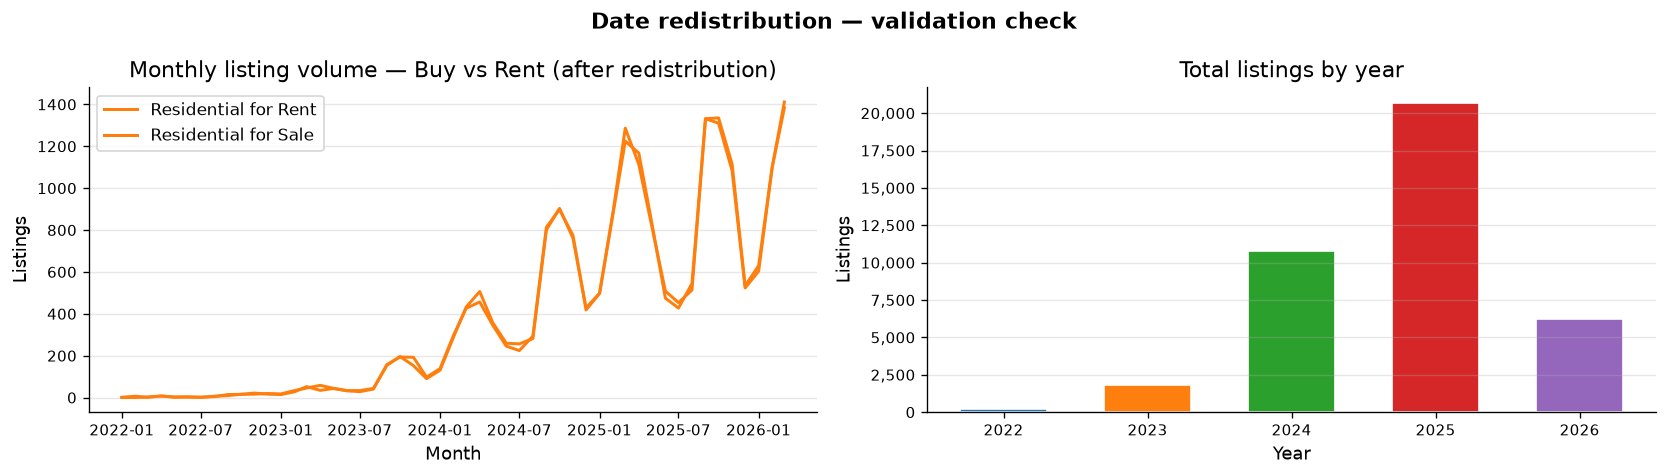

In [65]:
# Step 6: check the redistribution looks right
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = (
    df.groupby([df["listed_date"].dt.to_period("M"), "offering_type"])
      .size()
      .reset_index(name="count")
)
monthly["period"] = monthly["listed_date"].dt.to_timestamp()

for ot, grp in monthly.groupby("offering_type"):
    clr = BUY_CLR if ot == "Buy" else RENT_CLR
    axes[0].plot(grp["period"], grp["count"], label=ot, color=clr, linewidth=1.8)

axes[0].set_title("Monthly listing volume — Buy vs Rent (after redistribution)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Listings")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

year_counts = df["listed_date"].dt.year.value_counts().sort_index()
bar_colors  = [palette[i] for i in range(len(year_counts))]

axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color=bar_colors, edgecolor="white", width=0.6)
axes[1].set_title("Total listings by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Listings")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Date redistribution — validation check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\eda_outputs_Cleaning/date_redistribution_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Clean each column

Now we go column by column. The pattern is the same each time: look at the raw values, understand the problem, fix it, confirm with a quick chart.

### 5.1 `offering_type` — simplify to Buy / Rent

The raw column has long strings like `"Residential for Sale"`. We re-derive it from the shorter `category` column, which already contains `buy` or `rent`.

In [66]:
print("Raw values (before):")
print(df["offering_type"].value_counts(dropna=False).head(10))

df["offering_type"] = (
    df["category"]
    .astype(str).str.strip().str.lower()
    .map({"buy": "Buy", "rent": "Rent"})
)

print()
print("Clean values (after):")
print(df["offering_type"].value_counts(dropna=False))

Raw values (before):
offering_type
Residential for Rent    19910
Residential for Sale    19802
NaN                         1
Name: count, dtype: int64

Clean values (after):
offering_type
Rent    19910
Buy     19803
Name: count, dtype: int64


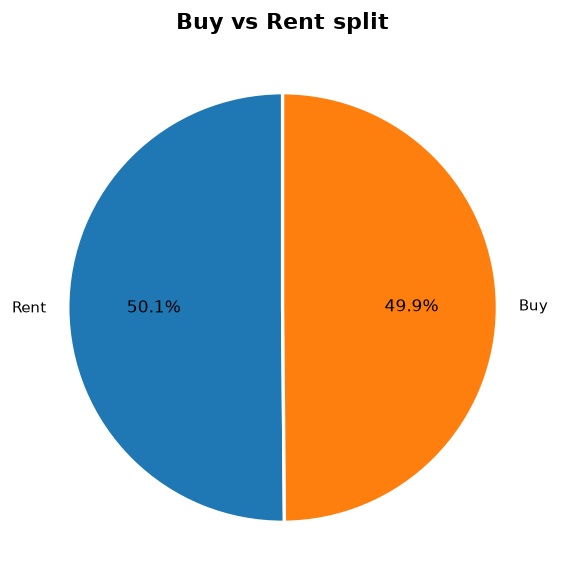

In [67]:
counts = df["offering_type"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values,
       labels=counts.index,
       colors=[BUY_CLR, RENT_CLR],
       autopct="%1.1f%%",
       startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Buy vs Rent split", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 `price_egp` — remove extreme outliers

Buy and Rent prices live in completely different ranges, so we remove outliers separately for each using the IQR method.

**IQR (Interquartile Range):** the middle 50% of your data (Q3 − Q1). Values below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` are outliers.

In [68]:
df["price_egp"] = pd.to_numeric(df["price_egp"], errors="coerce")
df = df[df["price_egp"] > 0].copy()

def iqr_mask(series, multiplier=1.5):
    q1  = series.quantile(0.25)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    return series.between(q1 - multiplier * iqr, q3 + multiplier * iqr)

rows_before = len(df)
masks = []

for otype in df["offering_type"].dropna().unique():
    idx  = df["offering_type"] == otype
    mask = iqr_mask(df.loc[idx, "price_egp"])
    masks.append(mask.reindex(df.index, fill_value=False))

if masks:
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    df = df[combined].copy()

print(f"Before: {rows_before:,} rows")
print(f"After : {len(df):,} rows  (removed {rows_before - len(df):,} outliers)")
print()
print(df.groupby("offering_type")["price_egp"].describe().map(lambda x: f"{x:,.0f}"))

Before: 39,712 rows
After : 36,870 rows  (removed 2,842 outliers)

                count        mean        std      min        25%        50%  \
offering_type                                                                 
Buy            18,198  10,604,869  7,531,456  113,116  5,000,000  8,400,000   
Rent           18,672      68,762     39,227    1,300     38,000     60,000   

                      75%         max  
offering_type                          
Buy            14,516,625  34,500,000  
Rent               90,000     190,000  


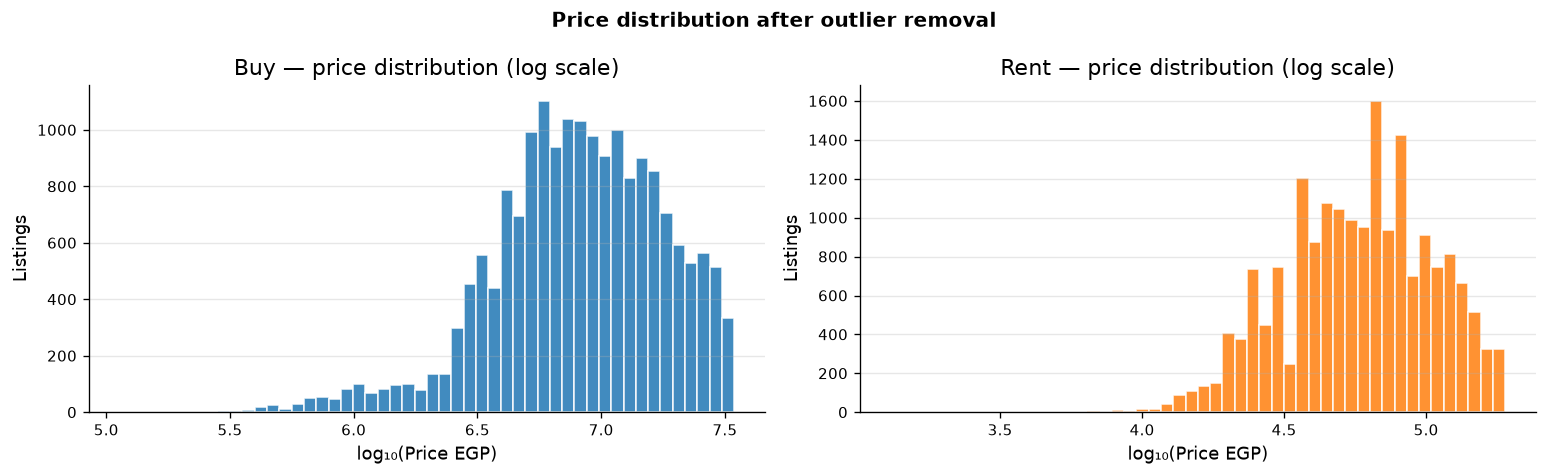

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, otype, color in zip(axes, ["Buy", "Rent"], [BUY_CLR, RENT_CLR]):
    data = df.loc[df["offering_type"] == otype, "price_egp"].dropna()
    ax.hist(np.log10(data), bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{otype} — price distribution (log scale)")
    ax.set_xlabel("log₁₀(Price EGP)")
    ax.set_ylabel("Listings")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Price distribution after outlier removal", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 `bedrooms` & `bathrooms` — convert to numbers

These come in as text. Edge cases to handle:
- `"Studio"` → `0`
- `"10+"` → `10`
- Everything non-numeric → NaN, then fill with the column median

In [70]:
def parse_room_count(series):
    s = series.astype(str).str.strip().str.lower()
    s = s.replace({"studio": "0", "10+": "10", "nan": np.nan})
    s = s.str.replace(r"[^\d.]", "", regex=True)
    s = s.replace("", np.nan)
    return pd.to_numeric(s, errors="coerce")

df["bedrooms"]  = parse_room_count(df["bedrooms"])
df["bathrooms"] = parse_room_count(df["bathrooms"])

df["bedrooms"]  = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

print("Bedroom  values:", sorted(df["bedrooms"].dropna().unique().tolist())[:15])
print("Bathroom values:", sorted(df["bathrooms"].dropna().unique().tolist())[:15])

Bedroom  values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Bathroom values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


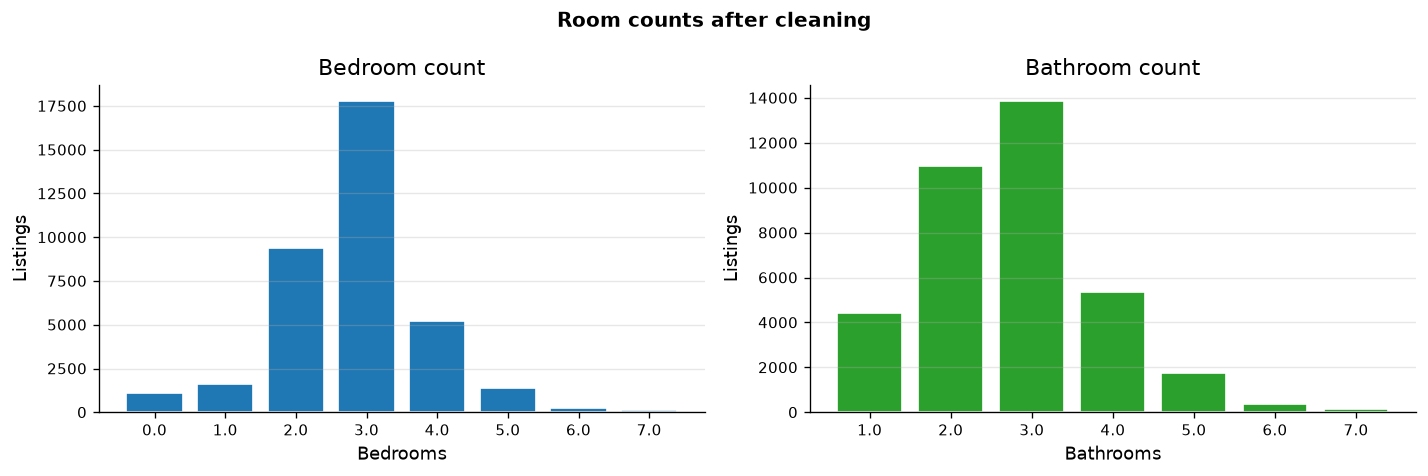

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, title in zip(
        axes,
        ["bedrooms", "bathrooms"],
        [palette[0], palette[2]],
        ["Bedroom count", "Bathroom count"]):

    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Listings")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Room counts after cleaning", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.4 `area_value` — check units & flag anomalies

All areas should be in sqm. We verify that, then flag anything physically unrealistic:
- **< 10 sqm** — smaller than a bathroom
- **> 50,000 sqm** — larger than a city block

We flag rather than drop — they might be commercial properties handled later.

In [72]:
df["area_value"] = pd.to_numeric(df["area_value"], errors="coerce")

if "area_unit" in df.columns:
    non_sqm = df["area_unit"].str.lower().ne("sqm") & df["area_unit"].notna()
    print(f"Rows with area_unit != 'sqm': {non_sqm.sum():,}")
    if non_sqm.sum() > 0:
        print(df.loc[non_sqm, "area_unit"].value_counts().head())

df["area_flag"] = ((df["area_value"] < 10) | (df["area_value"] > 50_000)).astype(int)

print(f"\nAnomalous area rows flagged: {df['area_flag'].sum():,}")
print(df.loc[df["area_flag"] == 1, "area_value"].describe())

Rows with area_unit != 'sqm': 0

Anomalous area rows flagged: 36
count   36.0000
mean     1.8333
std      1.5399
min      1.0000
25%      1.0000
50%      1.0000
75%      2.0000
max      6.0000
Name: area_value, dtype: float64


### 5.5 `furnished` — standardise to 3 categories

The raw column has many different spellings. We map everything to **Furnished**, **Unfurnished**, or **Semi-Furnished**.

In [73]:
print("Raw values (before):")
print(df["furnished"].value_counts(dropna=False).head(15))

FURNISHED_MAP = {
    "yes": "Furnished", "furnished": "Furnished", "fully furnished": "Furnished",
    "no": "Unfurnished", "unfurnished": "Unfurnished",
    "semi": "Semi-Furnished", "semi-furnished": "Semi-Furnished",
    "semi furnished": "Semi-Furnished", "partly": "Semi-Furnished",
    "partially": "Semi-Furnished",
}

df["furnished"] = (
    df["furnished"]
    .astype(str).str.strip().str.lower()
    .map(FURNISHED_MAP)
    .fillna("Unfurnished")
)

print("\nClean values (after):")
print(df["furnished"].value_counts())

Raw values (before):
furnished
YES       11814
NO        10338
NaN        7771
PARTLY     6947
Name: count, dtype: int64

Clean values (after):
furnished
Unfurnished       18109
Furnished         11814
Semi-Furnished     6947
Name: count, dtype: int64


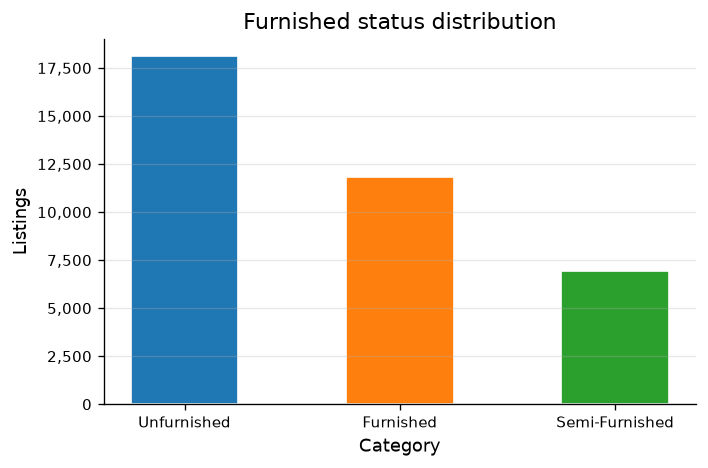

In [74]:
counts     = df["furnished"].value_counts()
bar_colors = [palette[i] for i in range(len(counts))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white", width=0.5)
ax.set_title("Furnished status distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Listings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 `amenities` — parse and create binary columns

Each cell looks like a Python list stored as text, e.g.:
```
"['Swimming Pool', 'Security', 'Parking', 'Gym']"
```

Steps:
1. Parse each cell into a real Python list
2. Count how often each amenity appears across all listings
3. Pick the top 20
4. Create one binary column per amenity (1 = has it, 0 = doesn't)

In [75]:
def parse_amenities(val):
    if pd.isna(val) or str(val).strip() in ("", "nan", "[]", "None"):
        return []
    s = str(val).strip()
    if s.startswith("["):
        try:
            items = ast.literal_eval(s)
            return [str(i).strip() for i in items if str(i).strip()]
        except Exception:
            pass
    return [a.strip() for a in s.split("|") if a.strip()]

df["amenities_list"] = df["amenities"].apply(parse_amenities)

all_amenities = [a for lst in df["amenities_list"] for a in lst]
amenity_freq  = Counter(all_amenities)

print(f"Total unique amenities: {len(amenity_freq)}")
print("\nTop 25:")
for name, cnt in amenity_freq.most_common(25):
    print(f"  {cnt:>6,}   {name}")

Total unique amenities: 21

Top 25:
  34,480   Balcony
  32,975   Security
  22,939   Covered Parking
  20,891   View of Landmark
  20,348   Shared Gym
  20,143   Lobby in Building
  20,109   Central A/C
  18,928   Kitchen Appliances
  18,585   Built in Wardrobes
  17,638   Shared Spa
  17,381   Shared Pool
  16,642   Walk-in Closet
  15,032   Study
  14,060   Children's Pool
  13,809   View of Water
  12,933   Private Garden
  11,688   Maids Room
   6,673   Private Pool
       1   Networked
       1   Dining in building
       1   Conference room


In [76]:
TOP_N   = 20
top_ams = [name for name, _ in amenity_freq.most_common(TOP_N)]

def make_col_name(amenity):
    return "amen_" + re.sub(r"[^a-z0-9]+", "_", amenity.lower()).strip("_")

for amenity in top_ams:
    col = make_col_name(amenity)
    df[col] = df["amenities_list"].apply(lambda lst: int(amenity in lst))

amenity_cols = [make_col_name(a) for a in top_ams]
print(f"Created {len(amenity_cols)} amenity binary columns.")

Created 20 amenity binary columns.


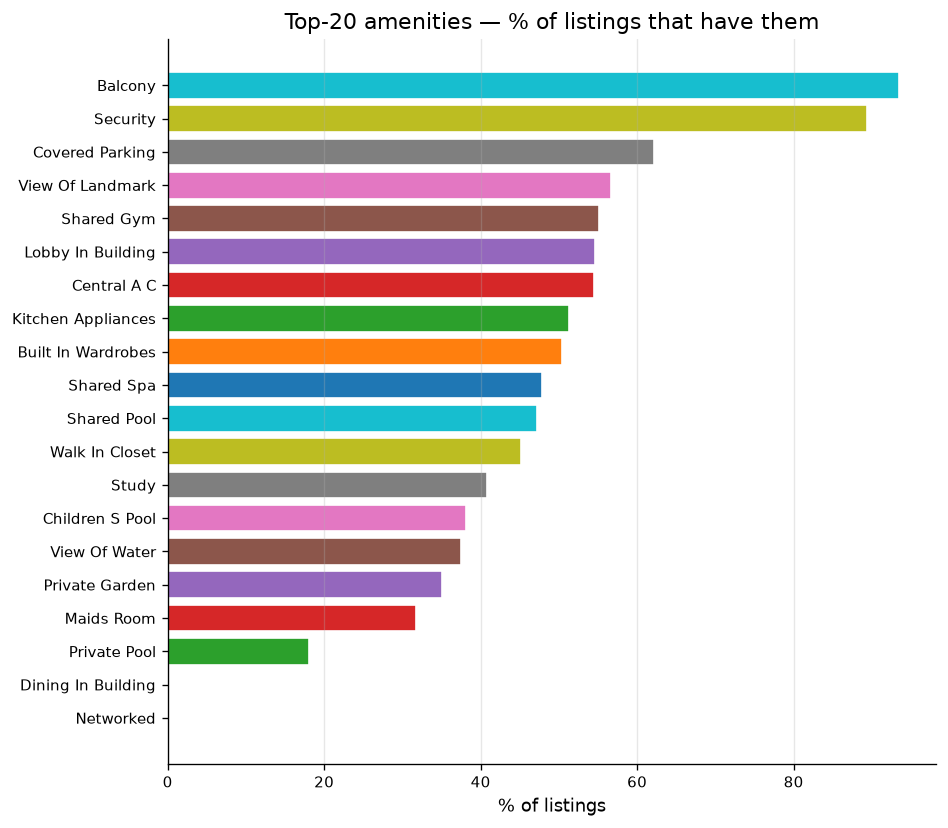

In [77]:
amen_pct   = df[amenity_cols].mean() * 100
amen_pct   = amen_pct.sort_values(ascending=True)
bar_colors = [palette[i % 10] for i in range(len(amen_pct))]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    amen_pct.index.str.replace("amen_", "").str.replace("_", " ").str.title(),
    amen_pct.values,
    color=bar_colors, edgecolor="white"
)
ax.set_title("Top-20 amenities — % of listings that have them")
ax.set_xlabel("% of listings")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 `description` — strip HTML & clean whitespace

Some descriptions contain raw HTML tags (`<br>`, `<p>`, `&nbsp;`). We remove those while keeping the actual text — both English and Arabic — intact.

In [78]:
HTML_TAG_RE    = re.compile(r"<[^>]+>")
HTML_ENTITY_RE = re.compile(r"&[a-zA-Z]{2,6};|&#?\w+;")
MULTI_SPACE_RE = re.compile(r"[ \t]+")

def clean_description(text):
    if pd.isna(text):
        return ""
    text = HTML_TAG_RE.sub(" ", str(text))
    text = HTML_ENTITY_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text)
    text = "\n".join(line.strip() for line in text.splitlines())
    return text.strip()

if "description" in df.columns:
    df["description"] = df["description"].apply(clean_description)
    for i, s in enumerate(df["description"].dropna().head(2).tolist(), 1):
        print(f"--- Sample {i} ---")
        print(s[:250])
        print()
else:
    print("'description' column not found — skipping.")

--- Sample 1 ---
Unit Description: Location: Villette Compound - Sodic - Fifth Settlement Area: 142 sq m Unit Layout: 2 bedrooms + 2 bathrooms + reception + kitchen The unit is fully furnished and equipped Price: 75,000 EGP annually We guarantee to save you time and 

--- Sample 2 ---
For Rent – Premium 196m² Fully Finished Apartment in New Giza | Park, Club & Golf View Live in one of New Giza’s most prime spots! This 196m² fully finished apartment offers a rare combination of luxury, space, and beautiful open views over the park,



## 6. Feature engineering

New columns derived from existing ones. These are what machine learning models in later notebooks will actually use.

| Column | Calculation | Why |
|---|---|---|
| `price_per_sqm` | price ÷ area | Compare properties of different sizes fairly |
| `total_rooms` | bedrooms + bathrooms | Quick size proxy |
| `days_since_listed` | scraped_at − listed_date | How long until it was captured |
| `listing_age_days` | reference_date − listed_date | How old the listing is |
| `is_furnished_binary` | 1 if Furnished, else 0 | ML needs numbers, not text |
| `amenity_count` | len(amenities_list) | Overall quality/luxury proxy |

In [79]:
df["price_per_sqm"] = np.where(
    df["area_value"] > 0,
    df["price_egp"] / df["area_value"],
    np.nan
)

df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

if "scraped_at" in df.columns and "listed_date" in df.columns:
    df["days_since_listed"] = (
        (df["scraped_at"] - df["listed_date"])
        .dt.total_seconds().div(86_400).round(1)
    )
    df.loc[df["days_since_listed"] < 0, "days_since_listed"] = np.nan

REF_DATE = pd.Timestamp("2026-03-05", tz="UTC")
listed = df["listed_date"]
if listed.dt.tz is None:
    listed = listed.dt.tz_localize("UTC")  # was naive → attach UTC
df["listing_age_days"] = (
    (REF_DATE - listed)
    .dt.total_seconds().div(86_400).round(1)
)
df.loc[df["listing_age_days"] < 0, "listing_age_days"] = np.nan

df["is_furnished_binary"] = (df["furnished"] == "Furnished").astype(int)
df["amenity_count"]       = df["amenities_list"].apply(len)

new_cols = ["price_per_sqm", "total_rooms", "days_since_listed",
            "listing_age_days", "is_furnished_binary", "amenity_count"]
print("Feature engineering done.")
print()
print(df[new_cols].describe().T.round(2))

Feature engineering done.

                          count        mean          std    min      25%  \
price_per_sqm       36,870.0000 38,202.2700 115,340.9700 5.5000 338.3500   
total_rooms         36,870.0000      5.5700       2.0100 1.0000   4.0000   
days_since_listed   36,870.0000     29.3000      17.3400 0.0000  14.0000   
listing_age_days    34,723.0000    353.9200     248.6000 0.0000 150.0000   
is_furnished_binary 36,870.0000      0.3200       0.4700 0.0000   0.0000   
amenity_count       36,870.0000      9.0900       5.0000 0.0000   5.0000   

                         50%         75%             max  
price_per_sqm       838.9900 60,000.0000 14,000,000.0000  
total_rooms           6.0000      6.0000         14.0000  
days_since_listed    29.0000     44.0000         60.0000  
listing_age_days    329.0000    507.0000      1,521.0000  
is_furnished_binary   0.0000      1.0000          1.0000  
amenity_count         8.0000     13.0000         18.0000  


## 7. Drop columns we don't need

IDs, contact details, raw URLs — nothing we'd analyse. Removing them keeps the file smaller and the column list readable.

In [80]:
DROP_COLS = [
    "internal_id", "detail_url", "listing_type", "reference",
    "agent_email", "agent_languages",
    "broker_id", "broker_email", "broker_phone",
    "contact_phone", "contact_whatsapp", "contact_email",
    "title",
]

cols_to_drop = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns.")
print(f"Current shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped 12 columns.
Current shape: 36,870 rows × 71 columns


## 8. Final null check and imputation

One last look at what's still missing. Then we fill:
- **Numeric** → median (more robust than mean for skewed data like prices)
- **Text** → `"Unknown"` so we can tell the difference between missing and empty

In [81]:

remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(f"Columns still containing nulls: {len(remaining)}")
print(remaining.to_string())

Columns still containing nulls: 7
completion_status    18694
payment_method       18555
subdistrict           6194
listing_age_days      2147
district               330
amenities               16
agent_name               4


In [82]:
# ── Numeric columns: fill with median ────────────────────────────────────────
for col in df.select_dtypes(include="number").columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())   # ← assignment, not inplace=True

# ── listing_age_days: may be float but set explicitly via .loc, double-check ─
if "listing_age_days" in df.columns and df["listing_age_days"].isna().any():
    df["listing_age_days"] = df["listing_age_days"].fillna(
        df["listing_age_days"].median()
    )

# ── Object / string columns: fill with "Unknown" ─────────────────────────────
for col in df.select_dtypes(include="object").columns:
    if df[col].isna().any():
        df[col] = df[col].fillna("Unknown")

# ── Nullable-typed columns (pd.StringDtype, pd.Int64Dtype, etc.) ─────────────
# pandas 2.x introduces nullable dtypes that select_dtypes misses — catch them
for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna("Unknown")

remaining_after = df.isnull().sum().sum()
print(f"Imputation done. Nulls remaining: {remaining_after}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Imputation done. Nulls remaining: 0
Final shape: 36,870 rows × 71 columns


In [83]:
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(f"Columns still containing nulls: {len(remaining)}")
print(remaining.to_string())

Columns still containing nulls: 0
Series([], )


## 9. Visual sanity check

A quick look at the most important numeric columns to make sure the distributions are reasonable.

Price columns are on log scale — property prices span several orders of magnitude (cheap apartments vs luxury villas), so a normal axis would squash everything into one corner.

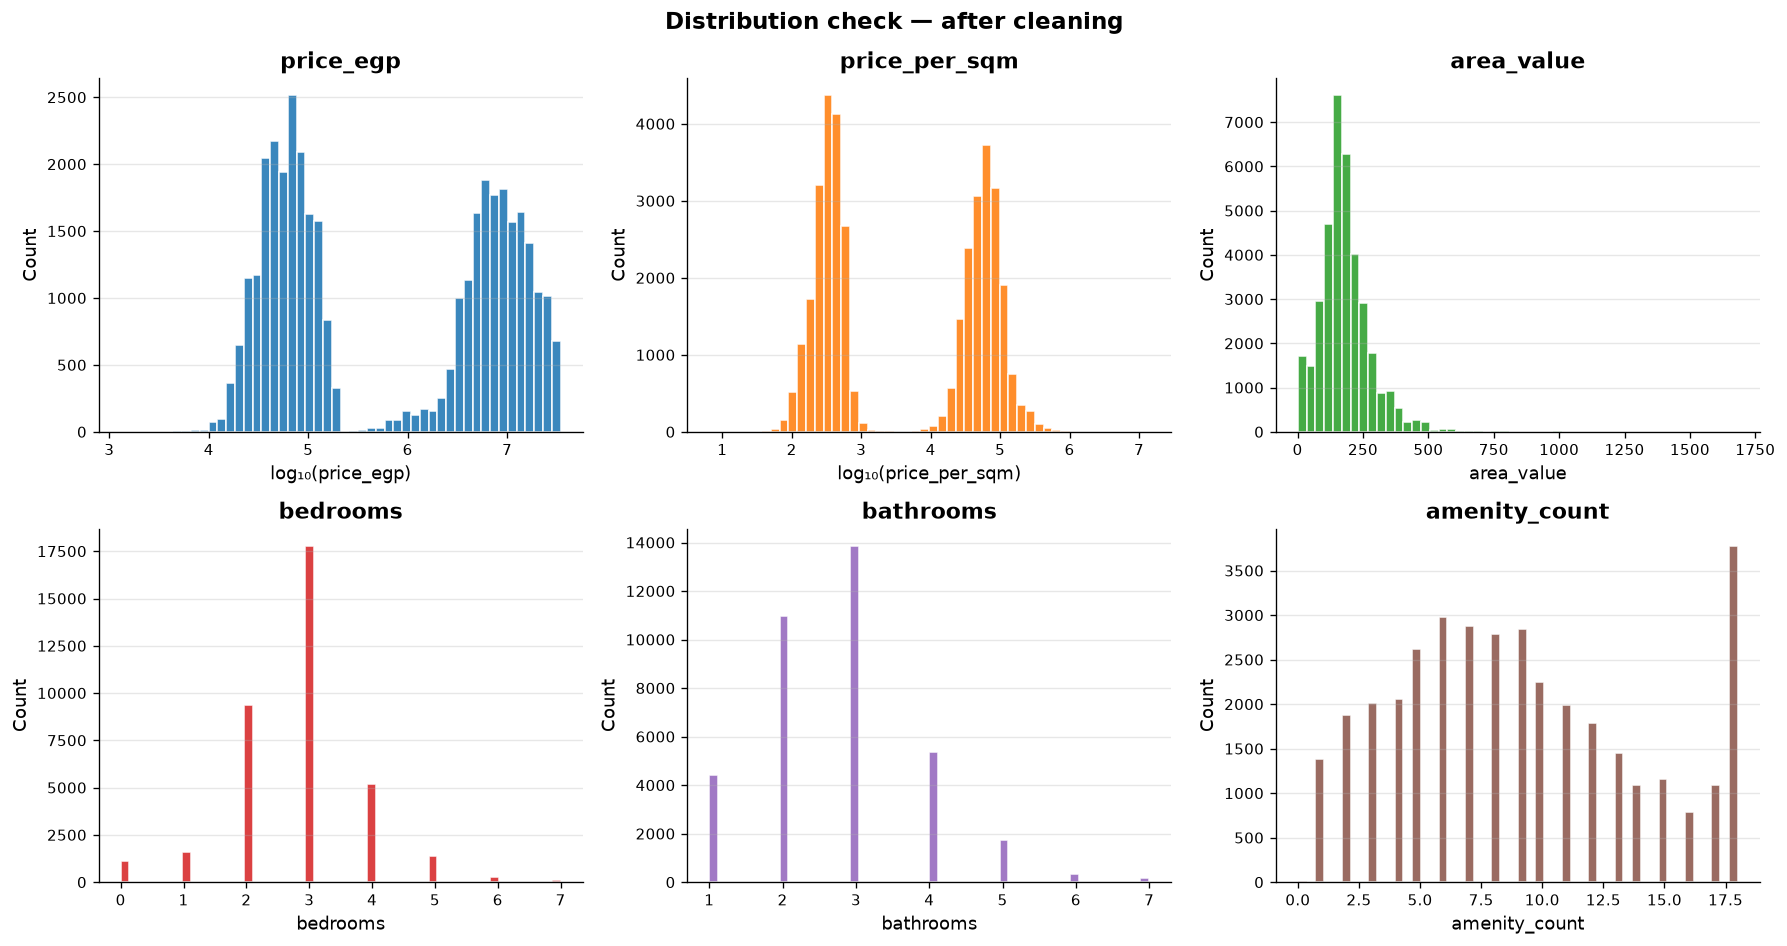

In [84]:
CHECK_COLS = ["price_egp", "price_per_sqm", "area_value",
              "bedrooms", "bathrooms", "amenity_count"]
CHECK_COLS = [c for c in CHECK_COLS if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes      = axes.flatten()

for i, (col, color) in enumerate(zip(CHECK_COLS, palette)):
    data = df[col].dropna()

    if "price" in col:
        data   = np.log10(data + 1)
        xlabel = f"log₁₀({col})"
    else:
        xlabel = col

    axes[i].hist(data, bins=50, color=color, edgecolor="white", alpha=0.88)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution check — after cleaning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\eda_outputs_Cleaning/distribution_check.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Export output files

Two files:
1. **`egypt_re_clean.csv`** — full cleaned dataset, used by every downstream notebook
2. **`egypt_re_amenities_binary.csv`** — listing_id + the 20 amenity columns, for Power BI

In [85]:
export_df  = df.drop(columns=["amenities_list"], errors="ignore")
CLEAN_PATH = os.path.join(OUTPUT_DIR, "egypt_re_clean.csv")

export_df.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")

print(f"Saved: {CLEAN_PATH}")
print(f"Shape: {export_df.shape[0]:,} rows × {export_df.shape[1]} columns")
print(f"Size : {os.path.getsize(CLEAN_PATH) / 1_048_576:.1f} MB")

Saved: F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv
Shape: 36,870 rows × 70 columns
Size : 54.7 MB


In [86]:
id_col = "listing_id" if "listing_id" in df.columns else df.columns[0]

amenity_export = df[[id_col] + amenity_cols].copy()
AMEN_PATH      = os.path.join(OUTPUT_DIR, "egypt_re_amenities_binary.csv")

amenity_export.to_csv(AMEN_PATH, index=False, encoding="utf-8-sig")

print(f"Saved: {AMEN_PATH}")
print(f"Shape: {amenity_export.shape[0]:,} rows × {amenity_export.shape[1]} columns")
print()
print("Amenity prevalence (% of listings with each amenity):")
print(
    (amenity_export[amenity_cols].mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .to_string()
)

Saved: F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_amenities_binary.csv
Shape: 36,870 rows × 21 columns

Amenity prevalence (% of listings with each amenity):
amen_balcony              93.5000
amen_security             89.4000
amen_covered_parking      62.2000
amen_view_of_landmark     56.7000
amen_shared_gym           55.2000
amen_lobby_in_building    54.6000
amen_central_a_c          54.5000
amen_kitchen_appliances   51.3000
amen_built_in_wardrobes   50.4000
amen_shared_spa           47.8000
amen_shared_pool          47.1000
amen_walk_in_closet       45.1000
amen_study                40.8000
amen_children_s_pool      38.1000
amen_view_of_water        37.5000
amen_private_garden       35.1000
amen_maids_room           31.7000
amen_private_pool         18.1000
amen_networked             0.0000
amen_dining_in_building    0.0000


## 11. Summary

The data is clean. Here's what we produced and what each cleaning decision was.

### Output files

| File | Used by |
|---|---|
| `egypt_re_clean.csv` | `02_eda.ipynb`, `04_nlp.ipynb`, `05_ml_prediction.ipynb`, `06_timeseries.ipynb`, Power BI, Tableau |
| `egypt_re_amenities_binary.csv` | `03_outlier_correlation.ipynb`, Power BI |

### Decisions made

| Step | What | Why |
|---|---|---|
| High-null columns | Dropped >40% missing (with exceptions) | Can't reliably fill more than 40% |
| Duplicates | Kept most recent `scraped_at` per `listing_id` | Freshest version of each listing |
| `listed_date` | Redistributed across 2022–2026 | All raw dates were in Feb–Mar 2026 (scraper artefact) |
| `offering_type` | Re-derived from `category` as Buy / Rent | Raw values were long inconsistent strings |
| `price_egp` | IQR 1.5× fence, applied per offering type | Buy and Rent have very different price ranges |
| `bedrooms` / `bathrooms` | Studio→0, 10+→10; NaN→median | Stored as strings with special values |
| `area_value` | Flagged anomalies, didn't remove | Let later analysis decide what to do |
| `furnished` | Mapped to 3 clean categories | Many different raw spellings |
| `amenities` | Parsed from string; top-20 binary columns | Needed for correlation and ML |
| `description` | Stripped HTML, normalised whitespace | HTML tags break NLP |
| Feature columns | Added `price_per_sqm`, `total_rooms`, etc. | Required by ML and EDA notebooks |
| Remaining nulls | Numeric→median, text→"Unknown" | Zero nulls in output |

Next: open `02_eda.ipynb`.